SALES PERFOMANCE ANALYSIS

In [1]:
#imorts
import pandas as pd


In [2]:
df1 = pd.read_csv("online_retail.csv")
df = df1.copy()
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
 9   Year         397884 non-null  int32         
 10  Month        397884 non-null  period[M]     
 11  Day          397884 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4), period[M](1)
memory usage: 36.4+ MB


In [ ]:
# Remove missing CustomerID 
df = df.dropna(subset=['CustomerID'])

# Remove returns (negative quantity)
df = df[df['Quantity'] > 0]

# Remove free items or invalid prices
df = df[df['UnitPrice'] > 0]

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [6]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Day'] = df['InvoiceDate'].dt.day

In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
Day            0
dtype: int64

In [10]:
df = df.drop_duplicates()
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Day
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,15.044656
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,7.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,15.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,22.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,31.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,8.652532


EXPLORATORY ANALYSIS

In [12]:
#Revenue trend over Time
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

Key Insight

Revenue increases significantly toward the end of the year, with the highest sales occurring between September and November, peaking in November. This indicates strong seasonal demand during the holiday period. Sales are noticeably lower in months such as February and April.

Recommendations

Increase inventory and operational capacity before the peak sales period (September–November).

Launch marketing campaigns ahead of the holiday season to maximize sales.

Introduce promotions during slower months like February and April to boost demand.

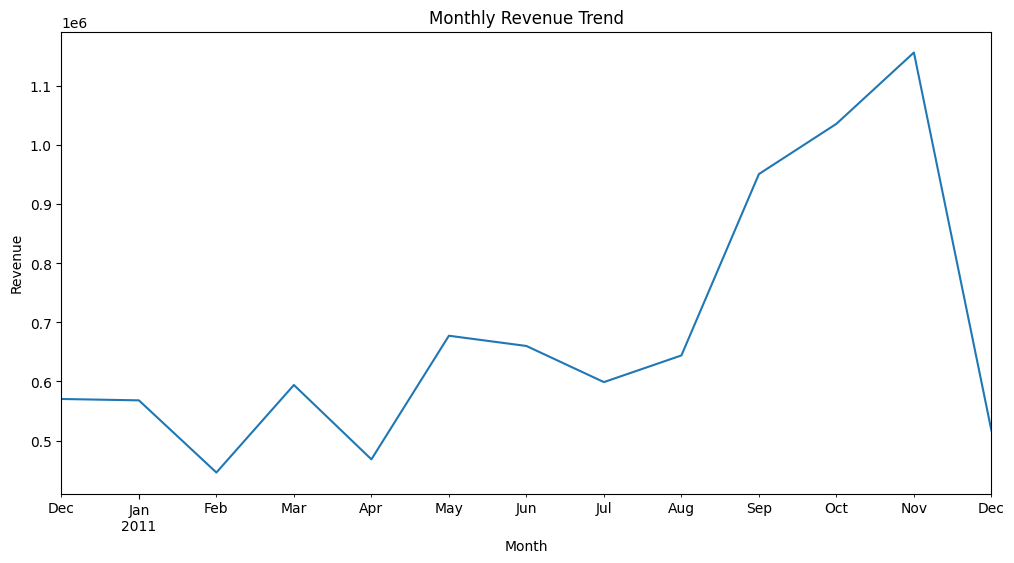

In [13]:


monthly_revenue.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [14]:
#top selling Products
top_products_qty = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_qty

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

Product Performance Insight

A small number of products account for a large portion of total sales volume. Items such as PAPER CRAFT, LITTLE BIRDIE, MEDIUM CERAMIC TOP STORAGE JAR, and WORLD WAR 2 GLIDERS ASSTD DESIGNS are among the most frequently purchased products, indicating strong and consistent customer demand.

Recommendations

Ensure consistent stock availability for top-selling products to avoid lost sales.

Prioritize marketing and promotions around these high-demand items.

Consider bundling popular products with slower-selling items to increase overall sales.

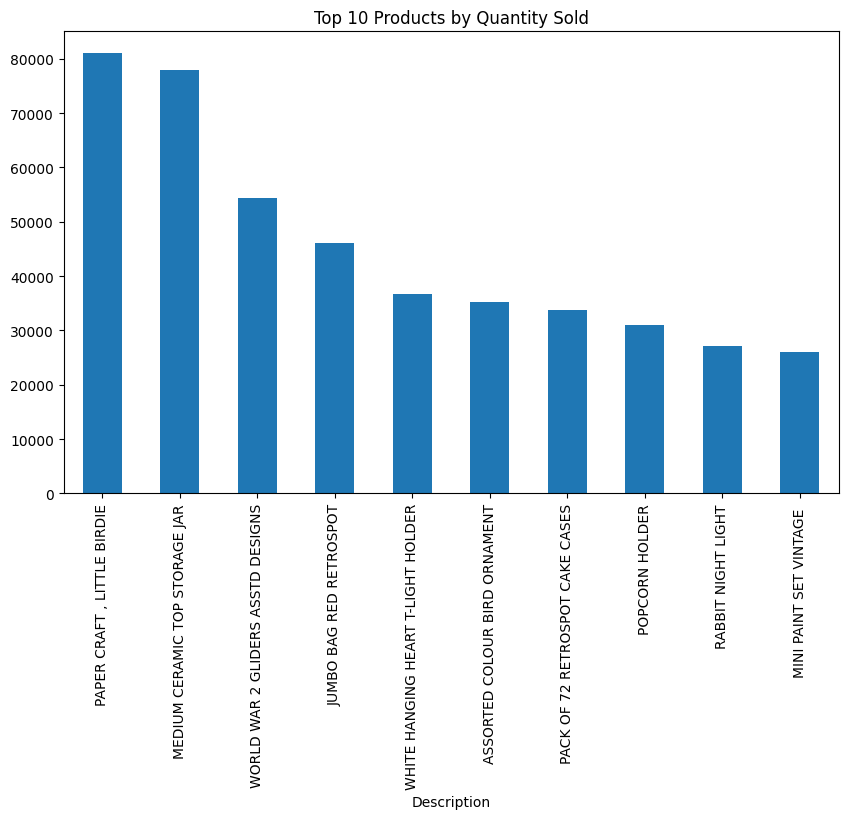

In [15]:
top_products_qty.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Products by Quantity Sold")
plt.show()

In [16]:
#top products by revenue
top_products_rev = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_rev

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

Product Revenue Insight

A small number of products generate a significant portion of total revenue. PAPER CRAFT, LITTLE BIRDIE, REGENCY CAKESTAND 3 TIER, and WHITE HANGING HEART T-LIGHT HOLDER are among the top revenue-generating items, indicating strong customer demand for these products.

Recommendations

Maintain adequate stock levels for top revenue-generating products.

Focus marketing and promotions on these high-performing items.

Consider expanding similar product lines to capitalize on existing demand.

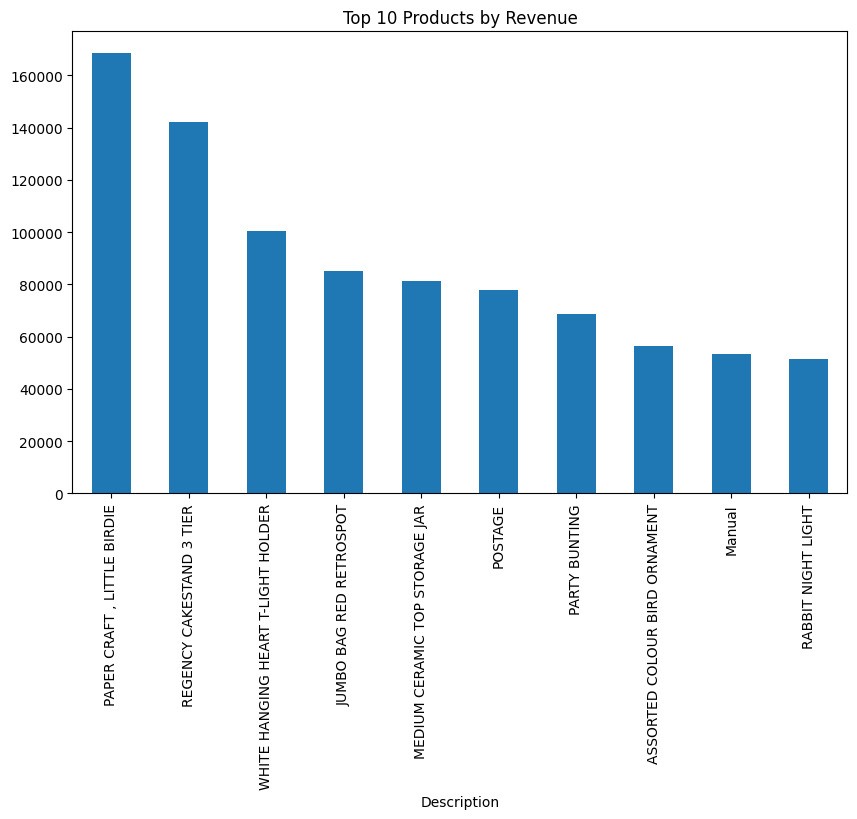

In [17]:
top_products_rev.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Products by Revenue")
plt.show()

In [18]:
#Total revenue by country
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

Regional Performance Insight

Revenue is heavily concentrated in the United Kingdom, which generates the vast majority of total sales. Other countries such as Netherlands, EIRE, Germany, and France contribute significantly smaller portions of revenue, while markets like Australia, Spain, and Switzerland represent smaller but potentially growing segments.

Recommendations

Continue strengthening the UK market, as it is the primary revenue driver.

Expand marketing and sales efforts in strong European markets such as the Netherlands, Germany, and France.

Explore growth opportunities in emerging markets like Australia and Spain through targeted promotions or partnerships.

In [20]:
#number of orders per country
country_orders = (
    df.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Australia            57
Portugal             57
Switzerland          51
Name: InvoiceNo, dtype: int64

Regional Sales Volume Insight

The United Kingdom dominates in terms of number of orders, with 16,646 invoices, far ahead of other countries. Germany, France, and EIRE follow, but each contributes only a small fraction of total orders. This confirms that sales are highly concentrated in the UK, while other markets have lower transaction volumes despite some revenue contribution.

Recommendations

Focus operational resources and marketing primarily on the UK to maintain and grow this strong base.

Develop strategies to increase order volume in European markets such as Germany, France, and EIRE, where revenue is moderate but order numbers are low.

Explore promotional campaigns or localized offerings in smaller markets to stimulate growth.

In [21]:
#average order value
country_orders = (
    df.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Australia            57
Portugal             57
Switzerland          51
Name: InvoiceNo, dtype: int64

Regional Sales Volume Insight

The United Kingdom dominates in orders, with 16,646 invoices, far exceeding any other country. Germany, France, and EIRE follow with much smaller volumes, indicating that most transactions are concentrated in the UK. Other countries have very few orders, even if revenue from some (like Netherlands or Germany) is notable.

Recommendations

Prioritize marketing, logistics, and customer support in the UK, the primary market.

Implement strategies to boost order volume in secondary markets (Germany, France, EIRE), such as targeted promotions or localized campaigns.

For smaller markets, consider strategic expansion initiatives to gradually grow transaction numbers without overextending resources.

In [ ]:
#top Customers
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64